# AG-HYPOPT · Trial 15

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_15. Fourteen trials recorded. Target rule wins, flat plateau 0.080-0.092 over
h_f ~3.5-5.5 and h_s ~2.5-8.0 (best exp6 0.0803); sim 0.1249 and power 0.1541 clearly worse; h_f edges
degrade. The picture has been stable for several trials; new trials keep sampling the plateau.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_15'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (14/5 trials)
ID |     ei | params
 1 | 2.6911 | {"bandwidth_rule": "target", "h_f_scale": 3.2466200193898356, "h_s_scale": 7.2875698273710405}
 2 | 0.9082 | {"bandwidth_rule": "target", "h_f_scale": 5.800008845736793, "h_s_scale": 6.290369467557982}
 3 | 2.6873 | {"bandwidth_rule": "sim", "h_f_scale": 4.451402733769921, "h_s_scale": 7.661166764741165}
 4 | 0.9165 | {"bandwidth_rule": "power", "h_f_scale": 5.45518675487998, "h_s_scale": 6.61052029968705}
 5 | 2.8134 | {"bandwidth_rule": "target", "h_f_scale": 3.194438518699329, "h_s_scale": 7.66270668982447}
 6 | 2.4000 | {"bandwidth_rule": "sim", "h_f_scale": 4.364148978655118, "h_s_scale": 7.168550740952685}
 7 | 2.3512 | {"bandwidth_rule": "target", "h_f_scale": 5.113293894680985, "h_s_scale": 7.870827871684268}
 8 | 0.6066 | {"bandwidth_rule": "target", "h_f_scale": 4.939983024971513, "h_s_scale": 4.771558981674831}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 5.5908437741613906, "h_s_scale": 10.894762990

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI concentrates on the target plateau. Highest is #5 (target 3.194/7.663, EI 2.813), then #1 (target
3.247/7.288, 2.691) and #7 (target 5.113/7.871, 2.351); the sim candidates (#3, #6) sit high but on the losing
rule.

I choose candidate 5 (target, h_f_scale 3.194, h_s_scale 7.663).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 3.194438518699329, 'h_s_scale': 7.66270668982447}
Running  1nW Trans05 ... 

μ 9.39 -> 6.68 | γ 8.5 -> 5.33 | NLL 0.22


Running  1nW Trans20 ... 

μ 17.32 -> 28.59 | γ 8.5 -> 5.55 | NLL 0.59


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 64.18 | γ 14.1 -> 14.15 | NLL 0.72


Running 3nW Trans100 ... 

μ 175.71 -> 100.82 | γ 14.1 -> 13.86 | NLL 0.71



Total: 7.8 min


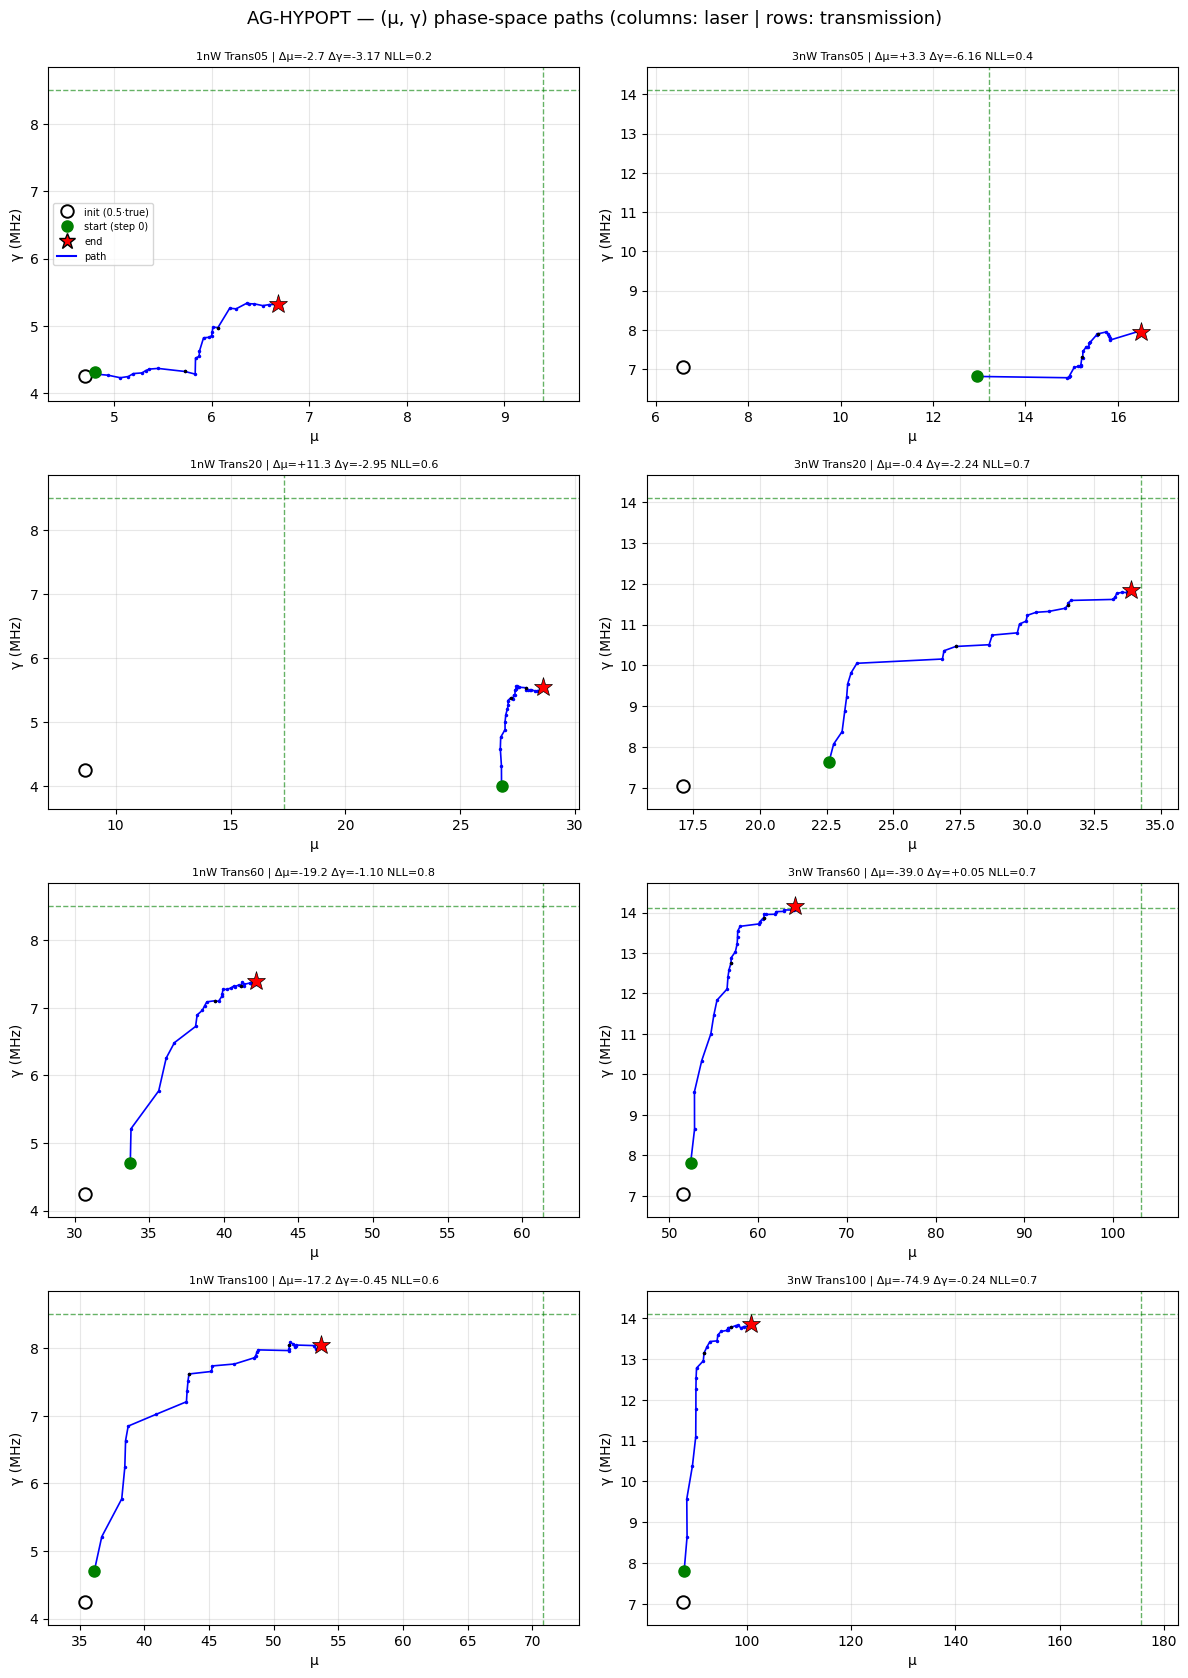

trial finished in 7.8 min
objective = 0.0826 ± 0.0273
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.68   -28.9 |     8.50    5.33   -37.3
1nW Trans20       17.32   28.59   +65.1 |     8.50    5.55   -34.8
1nW Trans60       61.37   42.16   -31.3 |     8.50    7.40   -12.9
1nW Trans100       70.82   53.66   -24.2 |     8.50    8.05    -5.3
3nW Trans05       13.20   16.51   +25.0 |    14.10    7.94   -43.7
3nW Trans20       34.28   33.90    -1.1 |    14.10   11.86   -15.9
3nW Trans60      103.20   64.18   -37.8 |    14.10   14.15    +0.4
3nW Trans100      175.71  100.82   -42.6 |    14.10   13.86    -1.7

weighted objective (T-graded, cap=1.0) = 0.0826 | diverged cells: 0
μ: RMSE 31.506 (rel 36.3%, bias -17.351) | γ: RMSE 2.810 (rel 24.9%, bias -2.032)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

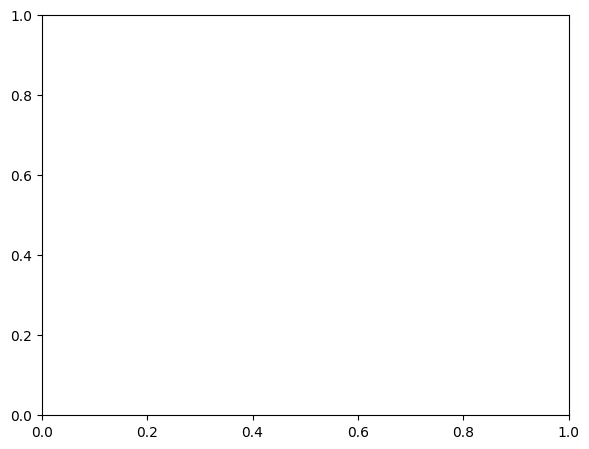

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0826 ± 0.0273, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 3.194, h_s_scale = 7.663.

Usual pattern (mu mixed-sign, +65.1 % at 1nW Trans20 and +25.0 % at 3nW Trans05; gamma near-exact at high
T, 3nW Trans60 +0.4 %). Another low-to-mid plateau sample at 0.0826 - near the campaign best but still above
exp6's 0.0803.

Twelfth plateau sample, inside the same 0.080-0.092 flat cloud with no trend. Nothing changes the campaign
picture.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 15 (target rule, h_f 3.194, h_s 7.663) scores objective 0.0826 ± 0.0273, the best campaign sample since trial_05 and consistent with the flat target plateau.
**Key insight:** The target plateau's twelve samples span 0.0803-0.0920 with no trend; the low-h_f half of the plateau is as good as the middle, and exp6's 0.0803 still stands as the best single value.

Notes for Anuar (optional, not acted on): none new.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 15 (target rule, h_f 3.194, h_s 7.663) scores objective 0.0826 ± 0.0273, the best campaign sample since trial_05 and consistent with the flat target plateau."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The target plateau's twelve samples span 0.0803-0.0920 with no trend; the low-h_f half of the plateau is as good as the middle, and exp6's 0.0803 still stands as the best single value."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_15 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_16.ipynb. Open it and follow its cells from the top.
